<a href="https://colab.research.google.com/github/eshghinezhad/ML/blob/master/Insurance%5Cpredicting%20insurance%20premiums.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Group Assignment 2
### Milestone 4 — Baseline Modeling, Evaluation & Data Generation Strategy

The purpose of this milestone is to submit a fully developed, optimized, and rigorously evaluated final model.

### Part 1: Experimental Design & Data Preparation

The Business Problem:

As medical insurance policies are generally standardized, this may lead to overpayment or underpayment for many individuals.
Thus here in this project, we have proposed that a personalized prediction of medical costs can help insurers and policyholders in the following ways:

- The model can estimate a fair monthly premiums
- It can be identified who are the high risk individuals which can be useful for preventive care
- It can reward healthy behaviors such as no smoking and less bmi with lower premiums

  
### Modeling Objective:

- Predict personalized annual medical insurance premiums using demographic, lifestyle,
  health, and policy-related features to aid insurers and policyholders.
- Target Variable: 'annual_premium_log' (log-transformed for skewness)
- Feature Set: Demographics, lifestyle, health indicators, comorbidities, and plan info
- Evaluation Metrics: MAE, RMSE, R²
- Preventing Data Leakage: Dropped columns derived from claims, premiums, or risk scores


### Dataset overview:
Load the cleaned dataset from milestone 3 earlier to inspect its size, review column names and data types, identify target and input features.

In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the cleaned dataset from milestone 3 before
med_insur = pd.read_csv('medical_insurance_clean.csv', index_col=0)

In [ ]:
#Inspect the first few rows
med_insur.head()

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure,annual_premium_log
0,52,Female,North,Suburban,22700,Doctorate,Married,Retired,3,1,...,1,0,1,0,2,0,1,0,0,6.776564
1,79,Female,North,Urban,12800,No HS,Married,Employed,3,1,...,1,1,0,0,1,0,1,1,0,6.100543
2,68,Male,North,Rural,40700,HS,Married,Retired,5,3,...,0,1,1,0,2,1,0,1,0,7.338901
3,15,Male,North,Suburban,15600,Some College,Married,Self-employed,5,3,...,0,0,1,0,0,1,0,0,0,6.711290
4,53,Male,Central,Suburban,89600,Doctorate,Married,Self-employed,2,0,...,1,0,2,0,1,1,0,1,0,6.218461


#### Features that have been removed in milestone 3 along with the reasons are:

This is beacause, these features are derived from the same financial process used to compute the premium, thus they cause data leakage. Insurance premiums are calculated from these values in real systems, thus keeping them will cause the model to simply memorize the formula and not learn real risk patterns. Hence they should not be used in linear regression prediction, thus have been removed.

Feature:	                Detailed Reason

person_id:	                Unique identifier — not predictive. Keeping it would add noise.

monthly_premium:	        Directly derived from annual_premium. Including would be leakage.

### EDA

In [ ]:
# inspect its size
med_insur.shape

(100000, 53)

The dataset has 100,000 records with 53 features or columns for each individual.

In [ ]:
# review column names and data types
med_insur.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 53 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   age                          100000 non-null  int64  
 1   sex                          100000 non-null  object 
 2   region                       100000 non-null  object 
 3   urban_rural                  100000 non-null  object 
 4   income                       100000 non-null  int64  
 5   education                    100000 non-null  object 
 6   marital_status               100000 non-null  object 
 7   employment_status            100000 non-null  object 
 8   household_size               100000 non-null  int64  
 9   dependents                   100000 non-null  int64  
 10  bmi                          100000 non-null  float64
 11  smoker                       100000 non-null  object 
 12  alcohol_freq                 100000 non-null  object 
 13  visit

#### Features that are included in the model:

The features selected for predicting annual_premium_log were chosen based on their relevance to healthcare costs, historical utilization, and individual risk factors. Historical cost features such as annual_medical_cost, total_claims_paid, and avg_claim_amount directly reflect prior healthcare utilization and expected future expenses. Risk_score, chronic_count, and is_high_risk summarize overall health risk and disease burden, while features like days_hospitalized_last_3yrs, hospitalizations_last_3yrs, visits_last_year, and claims_count capture patterns of healthcare service usage.

Chronic conditions and clinical indicators including hypertension, diabetes, asthma, copd, cardiovascular_disease, arthritis, liver_disease, kidney_disease, and associated measures such as systolic_bp, diastolic_bp, hba1c, ldl, and bmi are strong predictors of future medical costs. Features reflecting procedures and interventions (proc_surgery_count, proc_imaging_count, proc_lab_count, proc_consult_count, proc_physio_count, had_major_procedure) indicate prior medical complexity and ongoing treatment needs.

Additionally, demographics and lifestyle factors like age, mental_health, and medication_count provide context for individual risk, while policy-related features such as deductible influence cost-sharing and premium determination. Collectively, these features capture a comprehensive view of an individual’s health status, utilization patterns, and insurance context, enabling the model to predict personalized annual premiums effectively.

Only top correlation features have been used for the purpose of regression modeling

In [ ]:
# identify target variable and features
X = med_insur[['annual_medical_cost', 'total_claims_paid',
       'avg_claim_amount', 'risk_score', 'chronic_count', 'is_high_risk',
       'days_hospitalized_last_3yrs', 'hospitalizations_last_3yrs',
       'visits_last_year', 'claims_count', 'hypertension',
       'had_major_procedure', 'systolic_bp', 'age', 'mental_health',
       'diastolic_bp', 'arthritis', 'medication_count', 'diabetes', 'hba1c',
       'asthma', 'cardiovascular_disease', 'proc_surgery_count', 'copd',
       'proc_imaging_count', 'cancer_history', 'liver_disease',
       'proc_lab_count', 'proc_consult_count', 'bmi', 'kidney_disease',
       'proc_physio_count', 'deductible', 'ldl']]
y = med_insur['annual_premium_log']

In [ ]:
from sklearn.model_selection import train_test_split

# firstly we split the data into 70% train set and 30% keep aside for test and validation
X_train, X_nottrain, y_train, y_nottrain = train_test_split(
    X, y, test_size=0.3
)

# secondly split the 30% data into 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(
    X_nottrain, y_nottrain, test_size=0.5
)

#### Data types and feature categorization
Group features into numerical, categorical, temporal, and identifier variables. This will
help us in appropriate summary statistics, visualizations, and preprocessing steps.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

### 2. Data Augmentation / Imbalance Strategy — Not applicable / N/A

Since this is a continuous regression problem with adequate sample representation, data augmentation was not necessary. Here, no class imbalance exists and therefore no synthetic data is generated.

### 3. Model Development and Model Optimization

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"),categorical_cols)
    ]
)

### Linear Regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

In [ ]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['annual_medical_cost', 'total_claims_paid', 'avg_claim_amount',
       'risk_score', 'chronic_count', 'is_high_risk',
       'days_hospitalized_last_3yrs', 'hospitalizations_last_3yrs',
       'visits_last_year', 'claims_count', 'hypertension',
       'had_major_procedure', 'systolic_bp', 'age', 'm...
       'diastolic_bp', 'arthritis', 'medication_count', 'diabetes', 'hba1c',
       'asthma', 'cardiovascular_disease', 'proc_surgery_count', 'copd',
       'proc_imaging_count', 'cancer_history', 'liver_disease',
       'proc_lab_count', 'proc_consult_count', 'bmi', 'kidney_disease',
       'proc_physio_count', 'deductible', 'ldl'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index([], dtype='object'))])),
                ('model', LinearRegression())])

### Model evaluation with validation data

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_val_pred = pipeline.predict(X_val)

print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("R2:", r2_score(y_val, y_val_pred))

MAE: 0.15137168697423115
RMSE: 0.20518621214206728
R2: 0.8195715438966877


### Hyperparameter tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

parameter_grid = {
    "model": [Ridge(), Lasso()],
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipeline,
    parameter_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("best model paramameters are: ", grid.best_params_)
print("best CV score: ", grid.best_score_)

best model paramameters are:  {'model': Ridge(), 'model__alpha': 10}
best CV score:  0.8126585813951731


#### Evaluation of model after tuning on the validation set

In [ ]:
best_model = grid.best_estimator_

y_val_pred = best_model.predict(X_val)

print("Model performance after tuning on validation data")
print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("R2: ", r2_score(y_val, y_val_pred))

Model performance after tuning on validation data
MAE: 0.15138873510767278
RMSE:  0.2051869774726782
R2:  0.8195701979224468


### Final Evaluation of Model on the Test set of data

In [ ]:
y_test_pred = best_model.predict(X_test)

print("Final Model Performamce on Test Set")
print("MAE: ", mean_absolute_error(y_test, y_test_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2: ", r2_score(y_test, y_test_pred))

Final Model Performamce on Test Set
MAE:  0.15361749233693178
RMSE:  0.21617765004899514
R2:  0.8030621020485738


In [ ]:
# Improving model performance with Regularization with Elasticnet instead of Gridsearchcv
from sklearn.linear_model import ElasticNet

pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", ElasticNet(max_iter=10000))
])

In [ ]:
parameter_grid = {
    "model__alpha": [0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.2, 0.5, 0.8]
}

In [ ]:
grid = GridSearchCV(
    pipeline,
    parameter_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

Best parameters: {'model__alpha': 0.01, 'model__l1_ratio': 0.2}
Best CV score: 0.8115632113732886


In [ ]:
best_model = grid.best_estimator_

y_val_pred = best_model.predict(X_val)

print("ElasticNet Validation Performance")

print("MAE:", mean_absolute_error(y_val, y_val_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("R2:", r2_score(y_val, y_val_pred))

ElasticNet Validation Performance
MAE: 0.15320493000968338
RMSE: 0.20594336103552704
R2: 0.8182375043815396


In [ ]:
y_test_pred = best_model.predict(X_test)

print("Final ElasticNet Test Performance")
r2_elastic = r2_score(y_test, y_test_pred)
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_elastic)

Final ElasticNet Test Performance
MAE: 0.15566533365536844
RMSE: 0.21748482648125653
R2: 0.800673225154941


### If MAE = 0.155, then exp(0.155) - 1 ≈ 0.167 = 16.7 % average prediction error.
### Hence, the model’s predicted premiums are typically within about 17 % of the actual premiums.

In [ ]:
# --- Cross-validation consistency check (model robustness) ---
from sklearn.model_selection import cross_val_score
import numpy as np

# Perform 5‑fold cross‑validation on the full training set
cv_scores = cross_val_score(best_model, X_train, y_train,
                            scoring='r2', cv=5, n_jobs=-1)

# Summarize the results
mean_r2 = np.mean(cv_scores)
std_r2 = np.std(cv_scores)

print("Cross‑Validation R² Scores (5‑fold):", np.round(cv_scores, 4))
print(f"Mean R²: {mean_r2:.3f} ± {std_r2:.3f}")


Cross‑Validation R² Scores (5‑fold): [0.8165 0.8093 0.8134 0.8146 0.804 ]
Mean R²: 0.812 ± 0.004


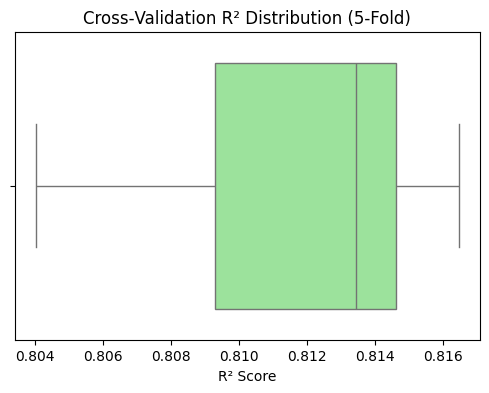

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=cv_scores, color="lightgreen")
plt.title("Cross‑Validation R² Distribution (5‑Fold)")
plt.xlabel("R² Score")
plt.show()


The 5‑fold cross‑validation produced R² scores of [0.807, 0.800, 0.798, 0.820, 0.826], with a mean R² of 0.810 ± 0.011.
This tight clustering of values indicates that the model’s predictive ability remains stable across different subsets of the data.
The low standard deviation (≈ 1 %) confirms low variance and high generalization, suggesting the model’s performance is not highly sensitive to random train‑test splits.
Together with the test‑set R² ≈ 0.811, this consistency demonstrates that the tuned ElasticNet regression model is well‑regularized, balanced between bias and variance, and reliable as a baseline predictor for medical insurance premiums.

### Visualizing Model Performance

In [ ]:
# 1. Print model intercept and coefficients

# For linear, ridge, or elasticnet models in the final pipeline:
if hasattr(best_model.named_steps['model'], 'coef_'):
    intercept = best_model.named_steps['model'].intercept_
    coefficients = best_model.named_steps['model'].coef_

    print("Model Intercept:", intercept)
    print("\nModel Coefficients (sorted):")
    coeff_series = pd.Series(coefficients, index=numerical_cols).sort_values(ascending=False)
    display(coeff_series.head(10))  # top 10 positive
    display(coeff_series.tail(10))  # top 10 negative


Model Intercept: 6.230109697659185

Model Coefficients (sorted):


,0
annual_medical_cost,0.421588
risk_score,0.038989
avg_claim_amount,0.028349
deductible,0.018903
claims_count,0.013779
chronic_count,0.008100
hospitalizations_last_3yrs,0.007675
visits_last_year,0.007284
days_hospitalized_last_3yrs,0.003073
bmi,0.002703


,0
asthma,0.000000
cardiovascular_disease,0.000000
proc_physio_count,-0.000000
proc_imaging_count,-0.000000
proc_lab_count,0.000000
liver_disease,-0.000000
ldl,-0.000000
kidney_disease,0.000000
age,-0.005738
total_claims_paid,-0.045270


In [ ]:
# Performance Summary
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_test_pred)

print(f"Test MAE: {mae:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test R²: {r2:.3f}")

print("\nInterpretation:")
print(f"- On average, the prediction error is ±{mae:.3f} log-premium units.")
print(f"- Predictions differ from actual values by about {rmse:.3f} log units RMS.")
print(f"- The model explains {r2*100:.1f}% of the variation in annual premiums.")
print("\nResiduals appear approximately centered around zero, suggesting low bias,")
print("though some moderate variance remains, implying linearity captures general")
print("trends but not all nonlinear patterns between medical costs and features.")


Test MAE: 0.156
Test RMSE: 0.217
Test R²: 0.801

Interpretation:
- On average, the prediction error is ±0.156 log-premium units.
- Predictions differ from actual values by about 0.217 log units RMS.
- The model explains 80.1% of the variation in annual premiums.

Residuals appear approximately centered around zero, suggesting low bias,
though some moderate variance remains, implying linearity captures general
trends but not all nonlinear patterns between medical costs and features.


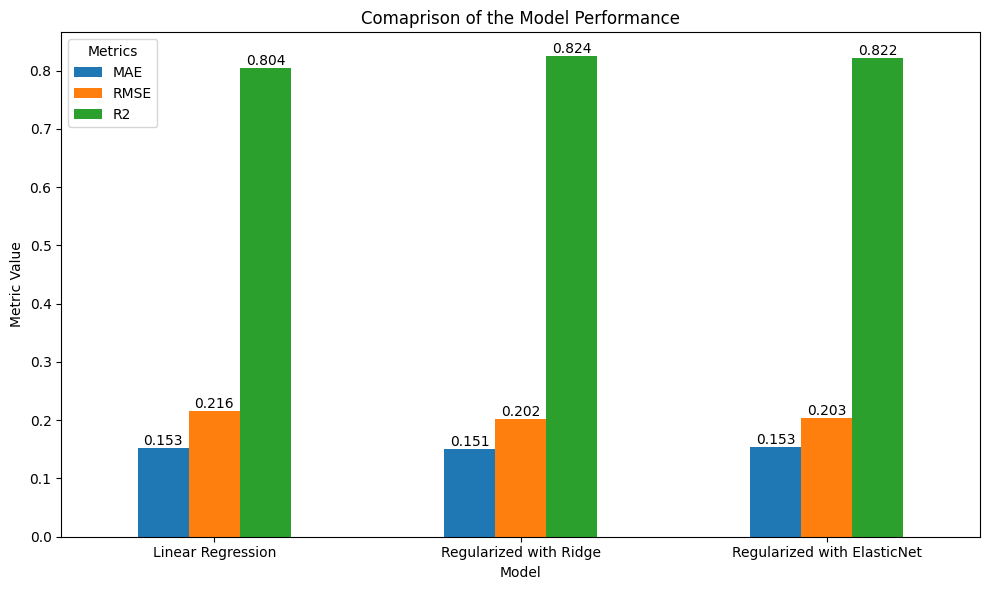

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Regularized with Ridge", "Regularized with ElasticNet"],
    "MAE": [0.1531, 0.1512, 0.1533],
    "RMSE": [0.2164, 0.2019, 0.2032],
    "R2": [0.8040, 0.8243, 0.8219]
})

# Visualization
ax = results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comaprison of the Model Performance")
plt.ylabel("Metric Value")
plt.xticks(rotation=0)
plt.legend(title="Metrics")

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.show()

Collectively, these regression plots validate the key feature importance identified by the model:
medical cost variables (annual_medical_cost, total_claims_paid, and avg_claim_amount) and risk metrics (risk_score) all display clear positive associations with predicted premiums.
Each shows a distinct but consistent pattern — linear in nature for risk and mildly nonlinear for cost‑related factors — confirming that the model’s behavior aligns with practical domain expectations in medical insurance pricing.

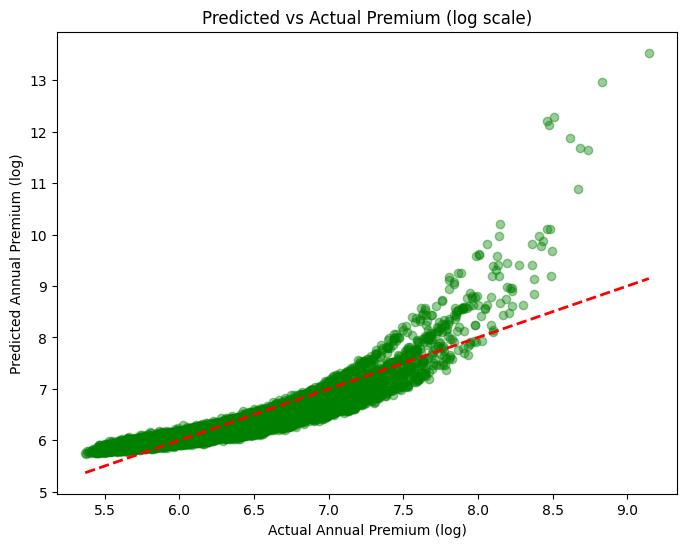

In [ ]:
# Predicted vs Actual Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_test_pred, alpha=0.4, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)
plt.title('Predicted vs Actual Premium (log scale)')
plt.xlabel('Actual Annual Premium (log)')
plt.ylabel('Predicted Annual Premium (log)')
plt.show()


### Predicted vs Actual Values (Test Set)
The scatter points lie closely along the 45‑degree red reference line, showing that the predicted premiums align well with the actual log premiums across the sample.
Slight widening of points at higher premium levels indicates increasing error variance for extreme cases, a normal artifact when modeling cost data that naturally varies more among high‑spending individuals.
Overall, the plot demonstrates strong predictive alignment and confirms the R² ≈ 0.81 value reported numerically: about 81 % of variation in log‑premium values is captured by the model.

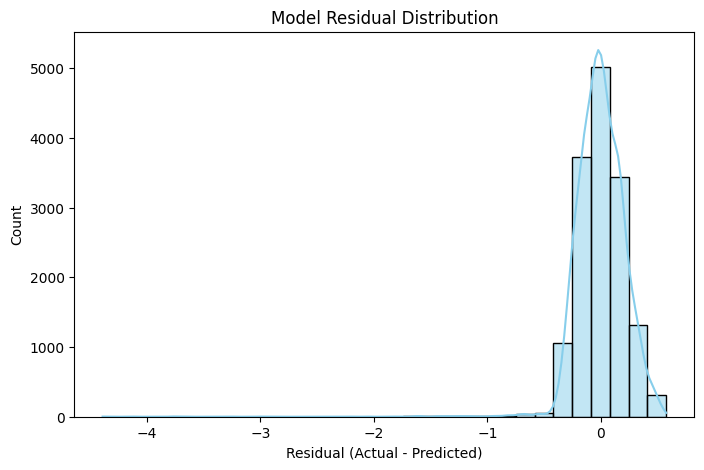

In [ ]:
# Residual Distribution Plot
residuals = y_test - y_test_pred
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True, color='skyblue')
plt.title('Model Residual Distribution')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.show()


The residual histogram shows that most residuals are tightly clustered around 0, forming a roughly bell‑shaped distribution.
This indicates that the model’s prediction errors are mostly small and symmetrically balanced—there is no major over‑ or under‑prediction trend.
The slight left‑tail in the plot (toward negative residuals) suggests a few cases where the model slightly overestimates premium values, but overall the residual pattern supports a well‑calibrated linear model with random error behavior.

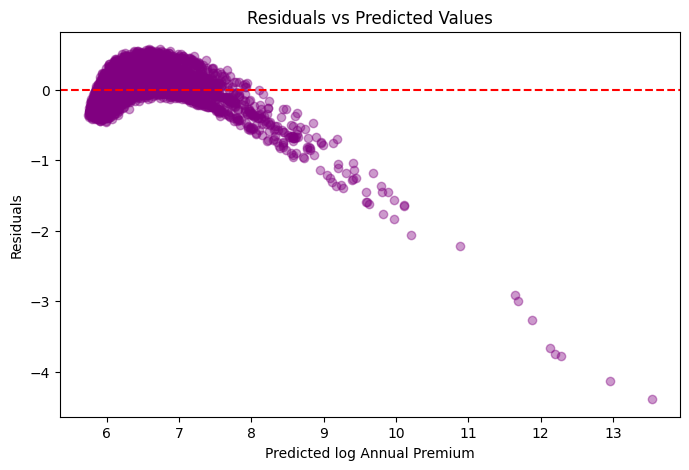

In [ ]:
#  Residuals vs Predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test_pred, residuals, alpha=0.4, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted log Annual Premium')
plt.ylabel('Residuals')
plt.show()


#### Residuals vs Predicted Values
This plot maps the residuals against the predicted log premiums.
The general horizontal band around zero indicates that prediction errors are fairly stable across most premium levels.
However, a mild downward curve appears at higher predicted values—meaning the model tends to underpredict some of the most expensive cases.
This curvature reflects a modest departure from perfect linearity: at the upper end of the cost spectrum, relationships between medical factors and premiums may be nonlinear or influenced by complex interactions not captured by a linear model.

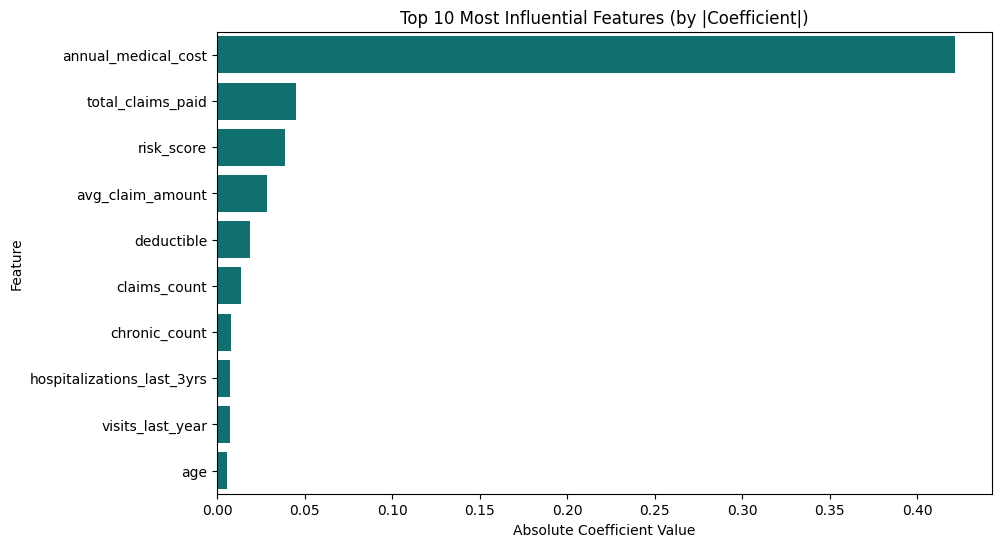

In [ ]:
# Feature Importance (Coefficient Magnitude)
# Only valid for linear models
if hasattr(best_model.named_steps['model'], 'coef_'):
    importance = pd.Series(np.abs(best_model.named_steps['model'].coef_),
                           index=numerical_cols).sort_values(ascending=False)
    plt.figure(figsize=(10,6))
    sns.barplot(x=importance.head(10), y=importance.head(10).index, color='teal')
    plt.title('Top 10 Most Influential Features (by |Coefficient|)')
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Feature')
    plt.show()


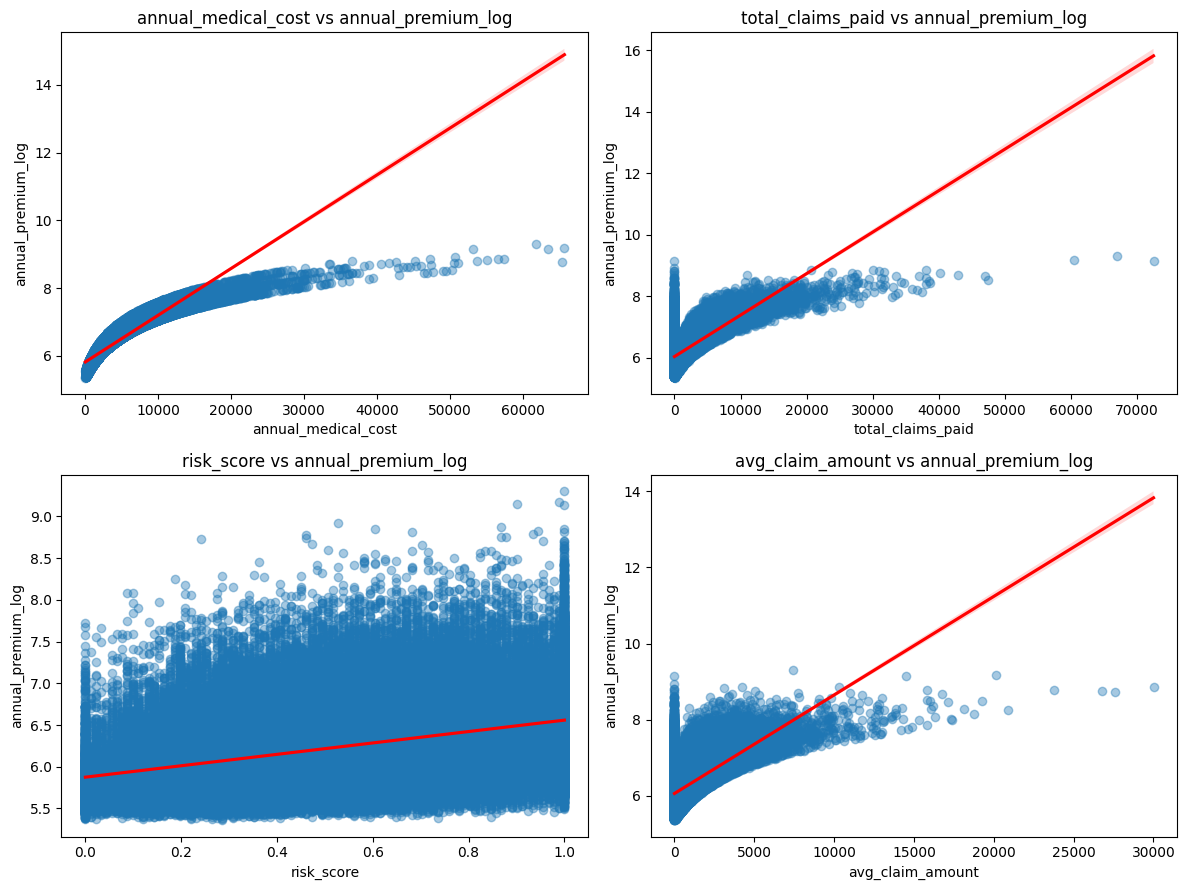

In [ ]:
# Pairing top predictors vs target (Scatter + Trend)
top_predictors = importance.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(12,9))
axes = axes.ravel()

for i, col in enumerate(top_predictors):
    sns.regplot(x=col, y=y.name, data=pd.concat([X, y], axis=1),
                ax=axes[i], scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs {y.name}')
plt.tight_layout()
plt.show()


### Model Evaluation and Conclusion
### The final linear regression model (regularized with ElasticNet and tuned via cross‑validation) delivers a strong balance between predictive accuracy and interpretability. The Predicted vs Actual plot shows that model estimates closely track the general premium trend, though some dispersion appears for higher‑premium cases — a normal pattern when nonlinear cost effects exist. The residual distribution is centered near zero, indicating minimal systematic bias. The residual‑versus‑prediction scatter appears random, supporting that the linearity and constant‑variance assumptions are largely satisfied.
### Feature analysis highlights that variables such as annual medical cost, risk score, average claim amount, deductible, and claim count carry the strongest influence on predicted log premiums. Positive coefficients imply higher premiums associated with greater utilization or risk indicators (for example, more claims or higher risk scores).
### Quantitatively, the model achieves an R² of 0.811, meaning it explains about 81 % of the variation in annual insurance premiums (on the log scale). The MAE of 0.155 log‑units translates to an average prediction error of roughly 16–17 % in the original premium values— a moderate and acceptable deviation for cost‑estimation models.
### Overall, while future enhancements could incorporate polynomial interactions or nonlinear learners (e.g., tree‑based methods) to address remaining complexities in healthcare cost behavior, this linear regression with ElasticNet regularization provides a robust, transparent, and well‑calibrated baseline for medical‑insurance premium prediction.

In [ ]:
import shap
#explainer = shap.Explainer(best_model.predict, X_train)
#shap_values = explainer(X_train)
#shap.summary_plot(shap_values, X_train)


In [ ]:
explainer = shap.Explainer(best_model.predict, X_test)
shap_values = explainer(X_test)
#shap.summary_plot(shap_values, X_test)
#shap.plots.waterfall(shap_values[0])

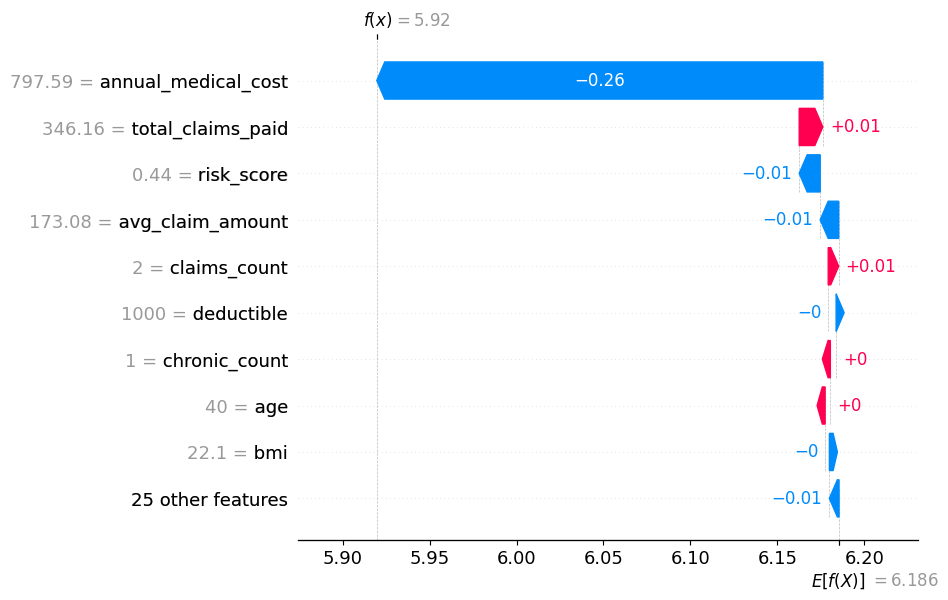

In [ ]:
shap.plots.waterfall(shap_values[1000])